In [ ]:
import torch
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split


from coronary_analysis.models.segmentation import CoronaryUNetCustom
from coronary_analysis.datasets import DCA1Dataset, get_dca1_pairs
from coronary_analysis.transforms import get_val_transforms
from coronary_analysis.utils import show_image

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [3]:
model = CoronaryUNetCustom(encoder_name="resnet18").to(device)
model.load_state_dict(
    torch.load(
        "../models/best_coronary_unet.pth", weights_only=True, map_location=device
    )
)
model.eval()

CoronaryUNetCustom(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

In [ ]:
IMAGE_DIR = "raw_datasets/DCA1/Database_134_Angiograms"
pairs = get_dca1_pairs(IMAGE_DIR)

_, val_pairs = train_test_split(pairs, test_size=0.25, random_state=42)

In [ ]:
BATCH_SIZE = 4
IMG_SIZE = 250

val_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    pairs=val_pairs,
    transform=get_val_transforms(IMG_SIZE),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

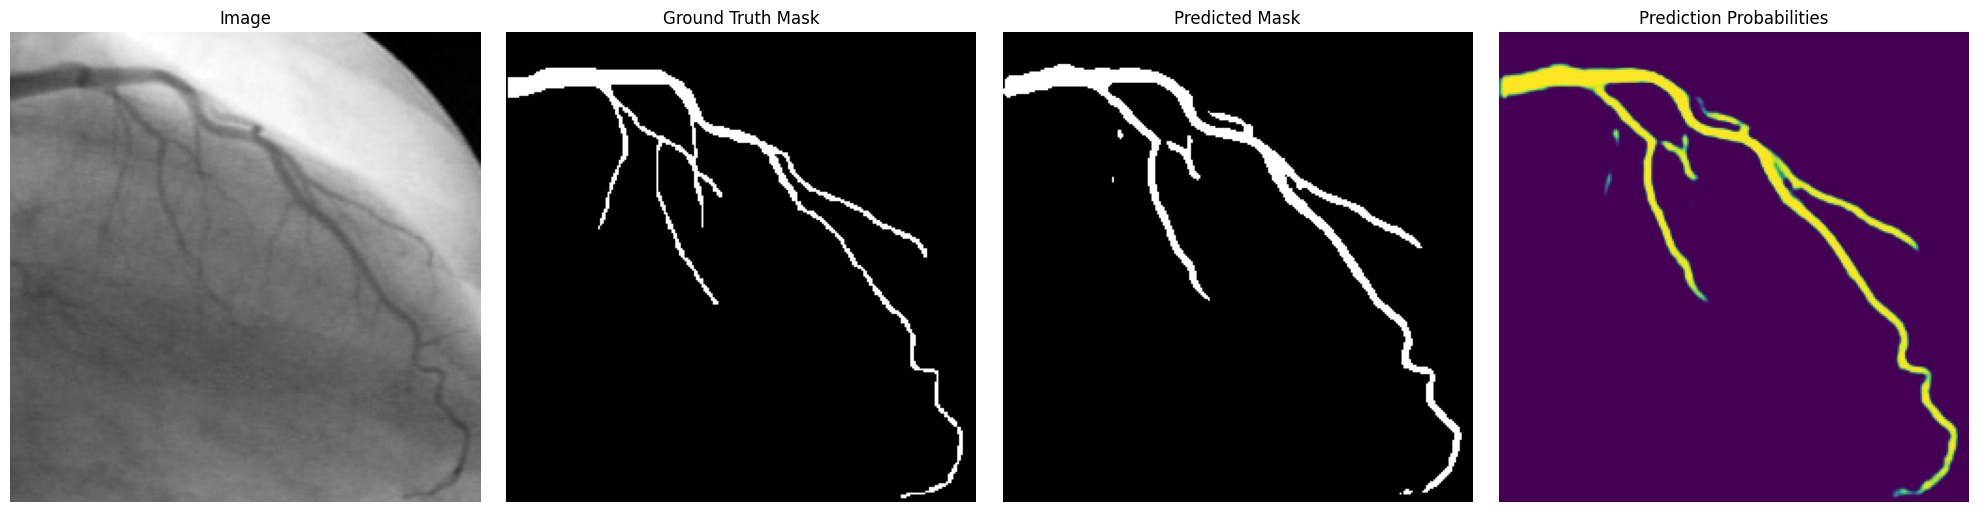

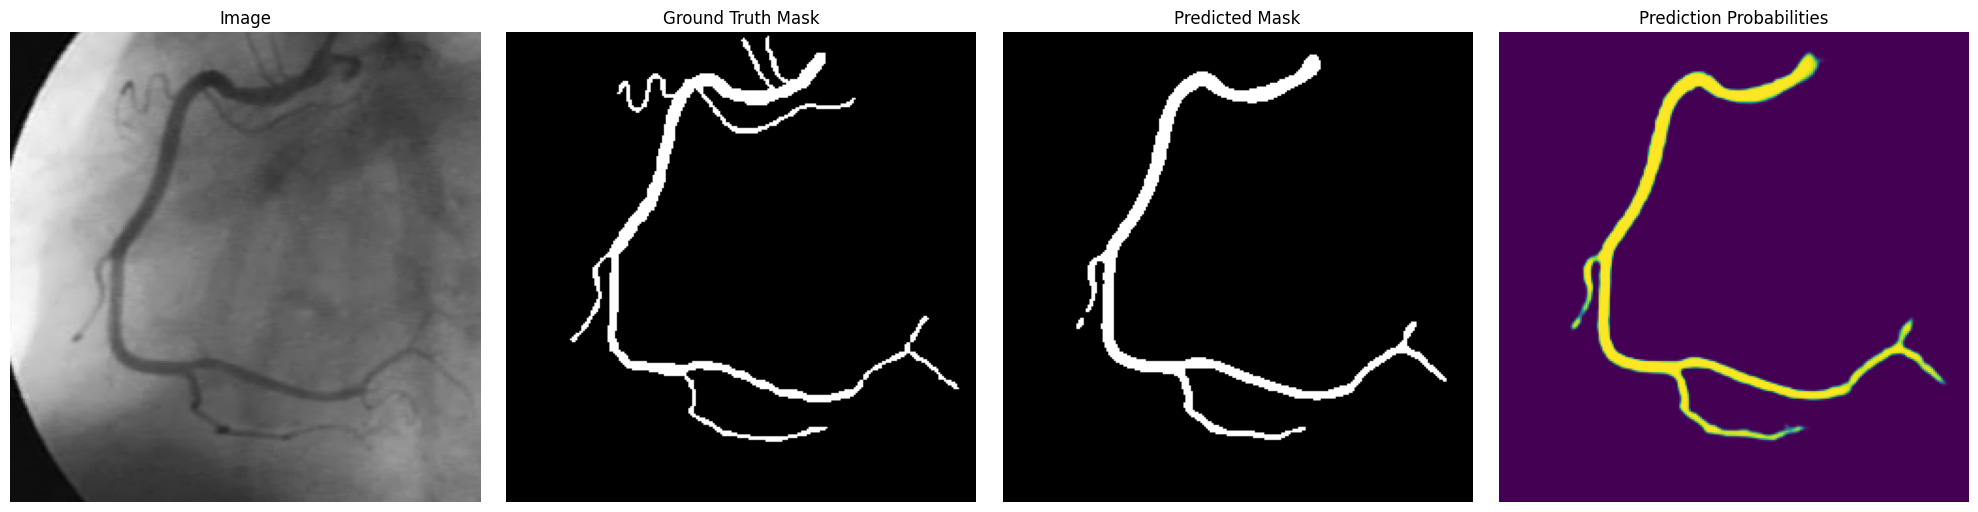

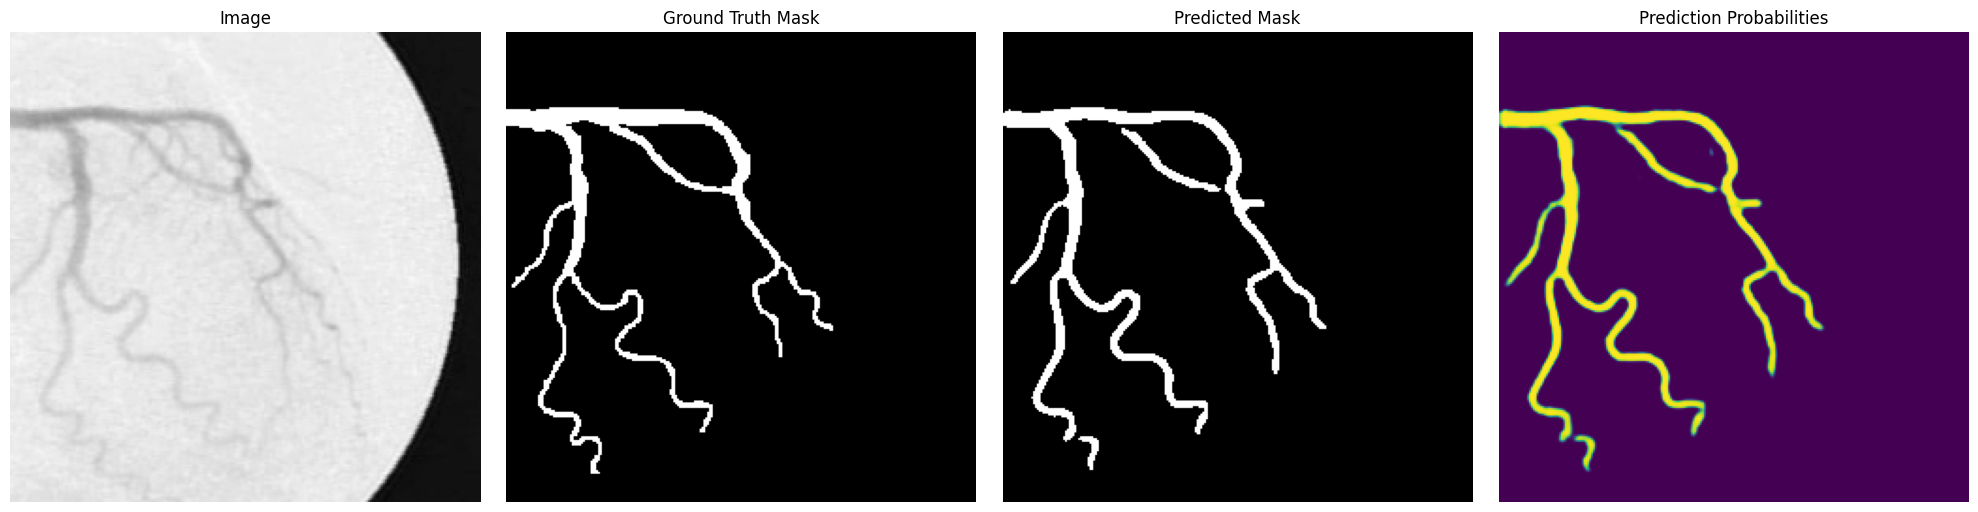

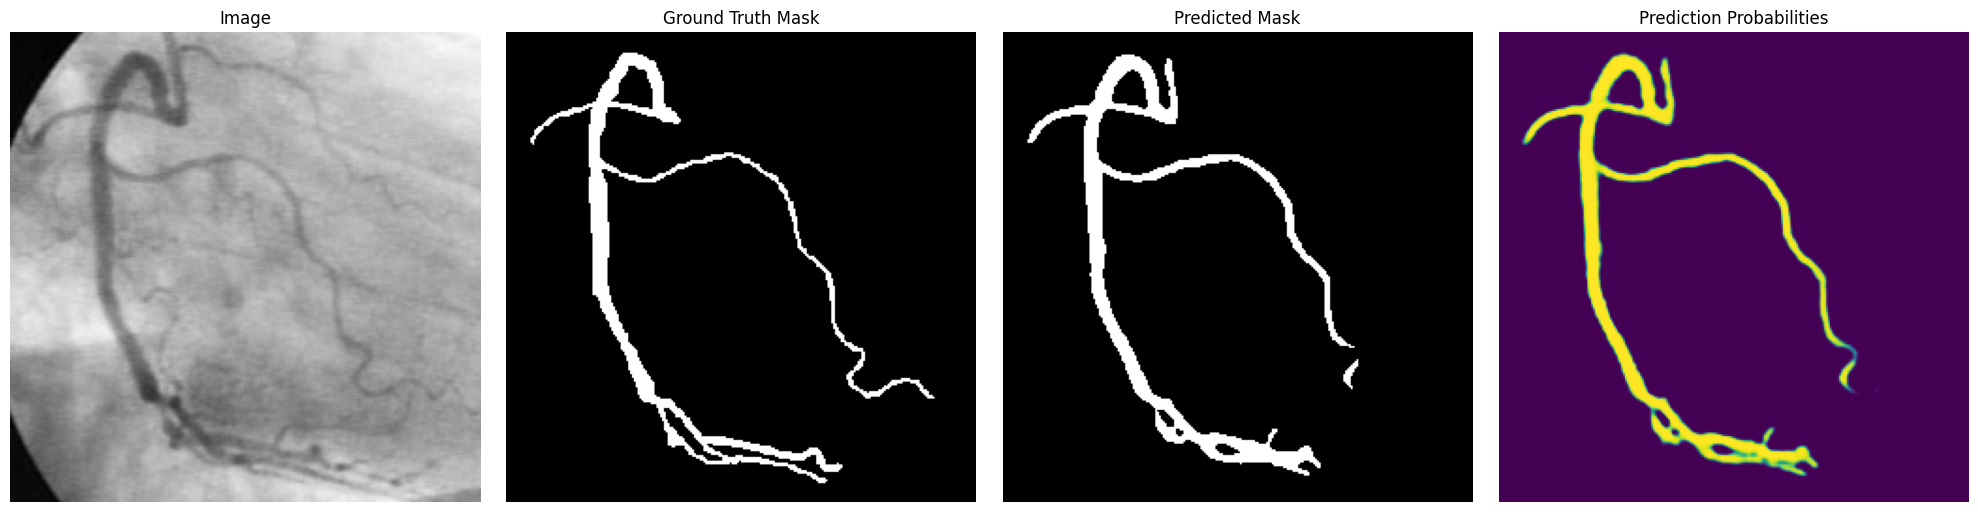

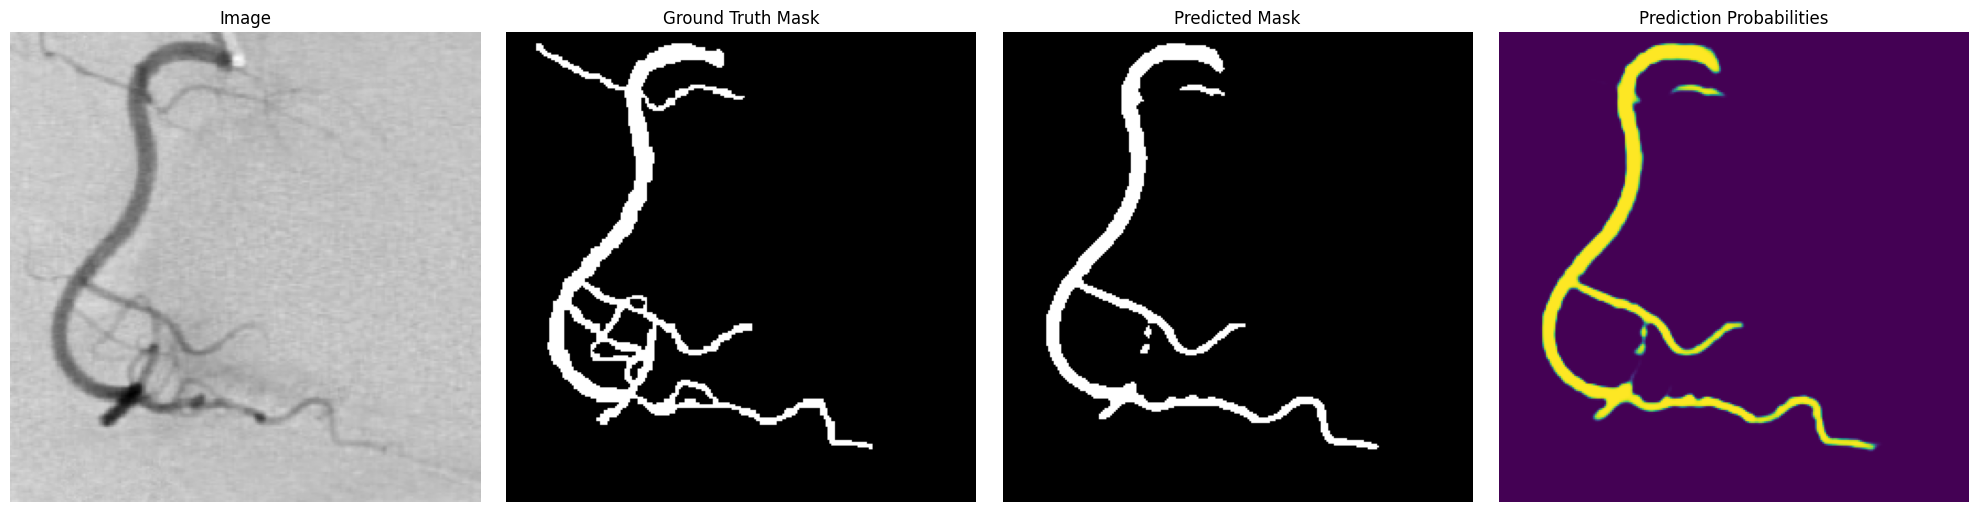

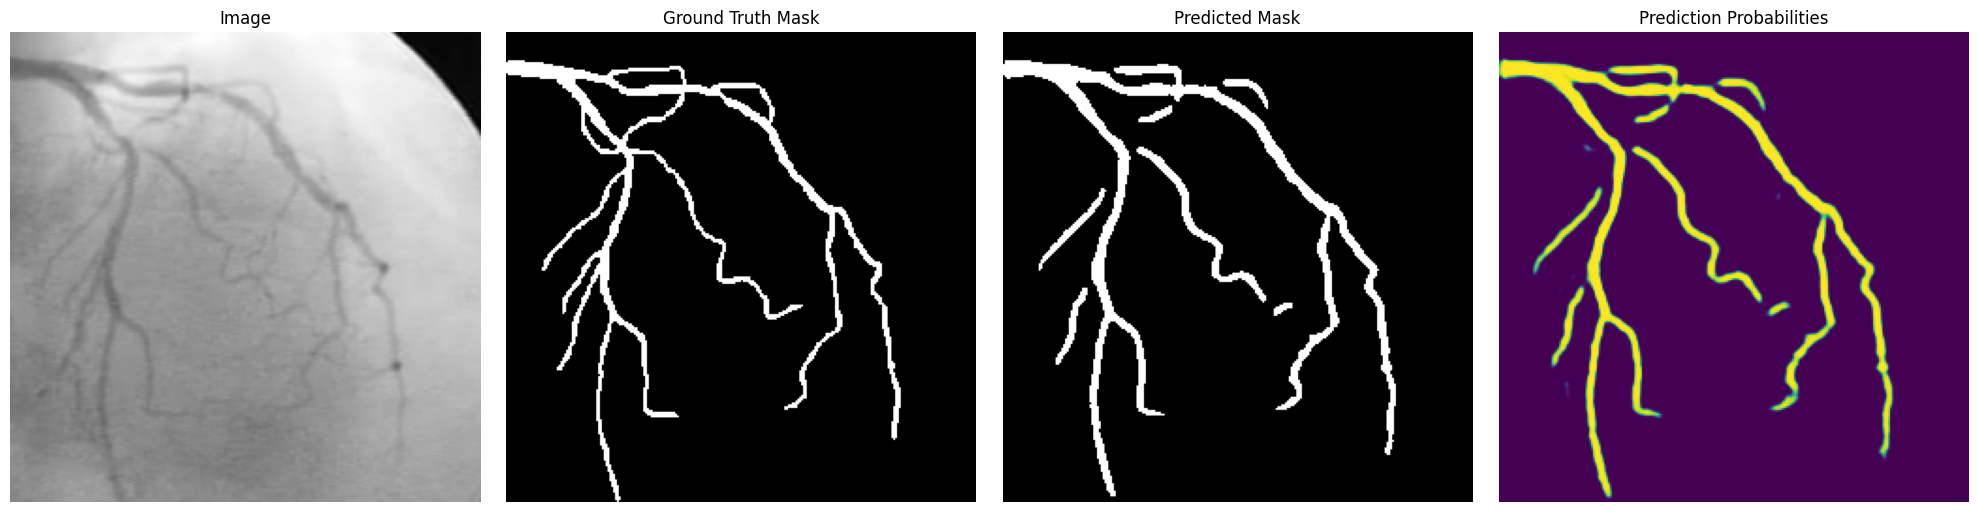

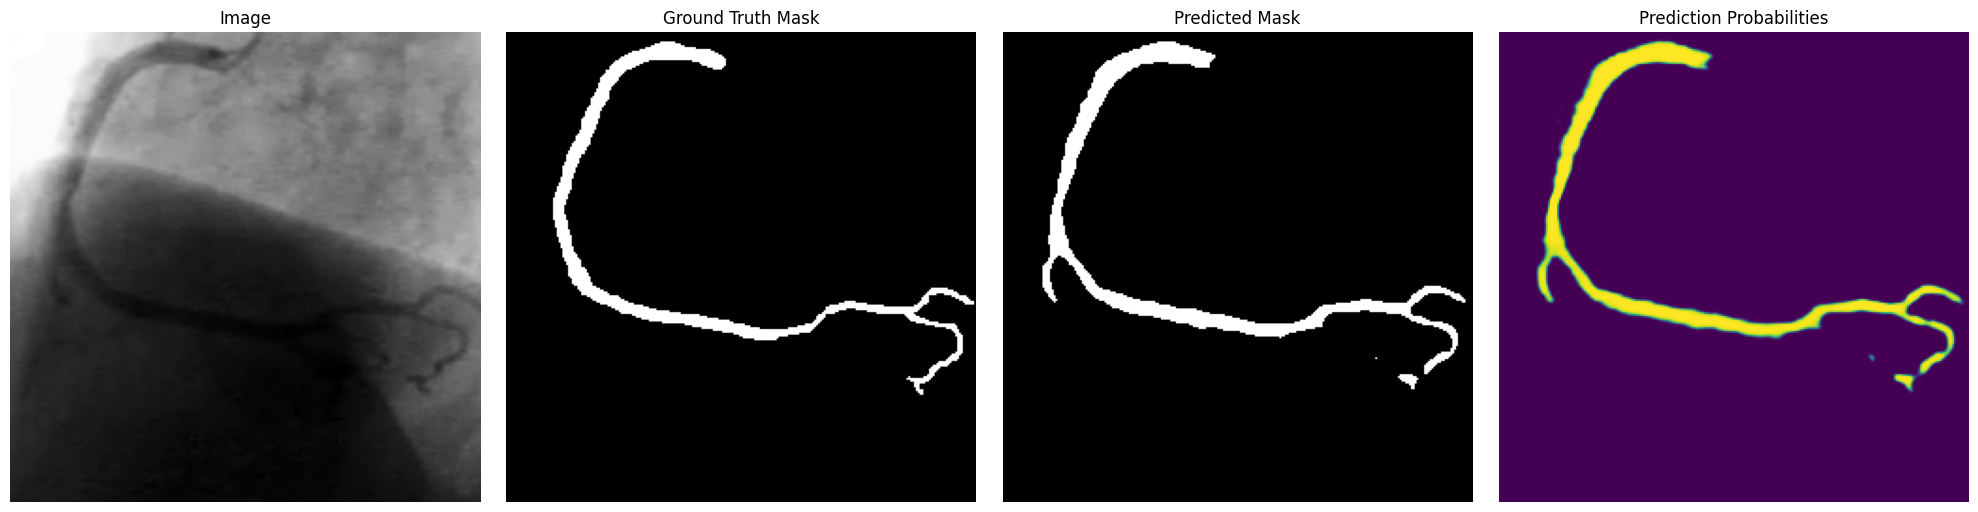

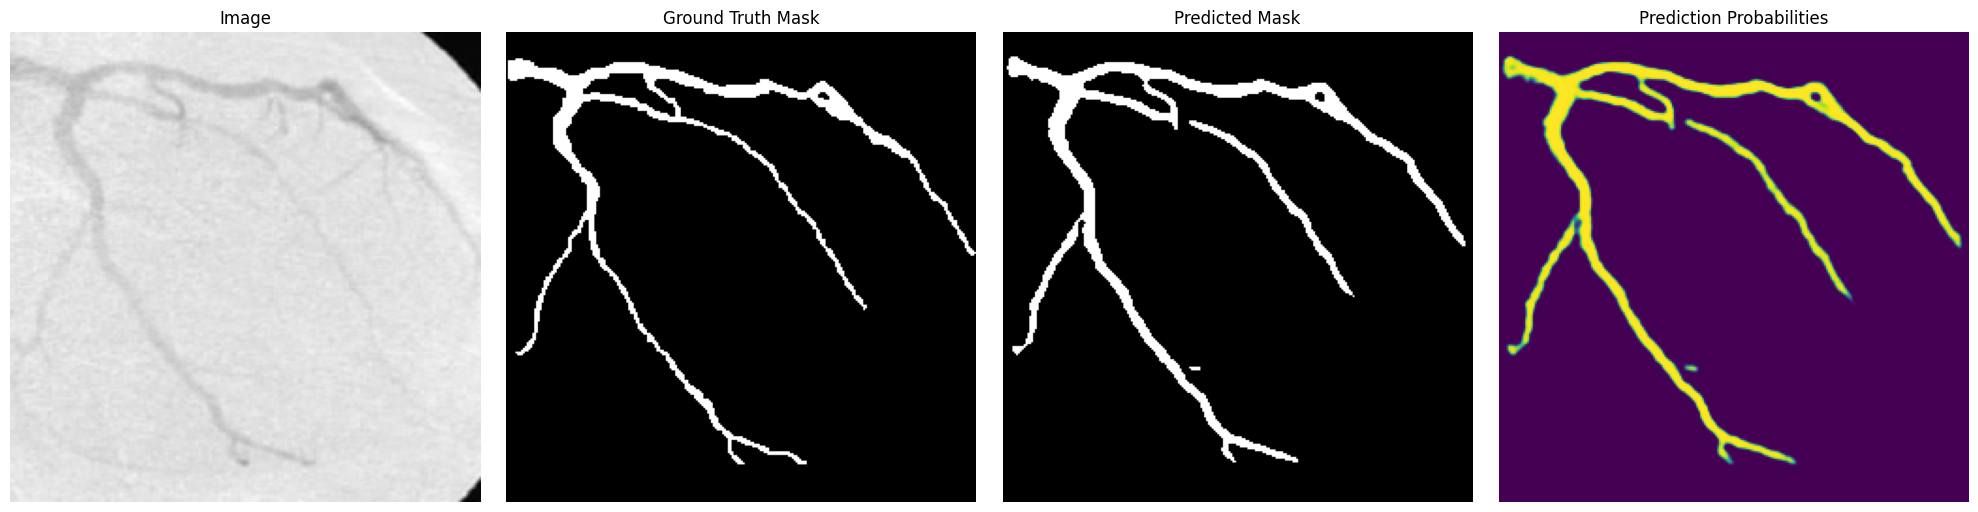

In [6]:
with torch.no_grad():
    val_loader_iter = iter(val_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=[
                    "Image",
                    "Ground Truth Mask",
                    "Predicted Mask",
                    "Prediction Probabilities",
                ],
                cmap=["gray", "gray", "gray", None],
            )